In [1]:
## Sales Analysis - Business Insights

## Objective
# To analyze retail sales data, compute key business KPIs, identify trends, and generate actionable insights using data visualization.

In [2]:
## Import Libraries

# Pandas is used for data handling, while Matplotlib and Seaborn are used for visualization.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Load Dataset

# The dataset is loaded into a Pandas DataFrame for analysis.

df = pd.read_csv("Sample_Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
## Inspect Dataset

# This step helps understand the structure of the dataset.

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
## Data Preparation

# The 'Order Date' column is converted into datetime format to enable time-based analysis.

# Clean column names
df.columns = df.columns.str.strip()

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create month column
df['Month'] = df['Order Date'].dt.to_period('M')

In [7]:
## Key Performance Indicators (KPIs)

# KPIs provide key business metrics such as total revenue, average order value, and top-performing regions.

# Total Revenue
total_revenue = df['Sales'].sum()

# Average Order Value
avg_order_value = df['Sales'].mean()

# Top Regions
top_regions = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("\nTop Regions:\n", top_regions)

Total Revenue: 2297200.8603
Average Order Value: 229.85800083049827

Top Regions:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


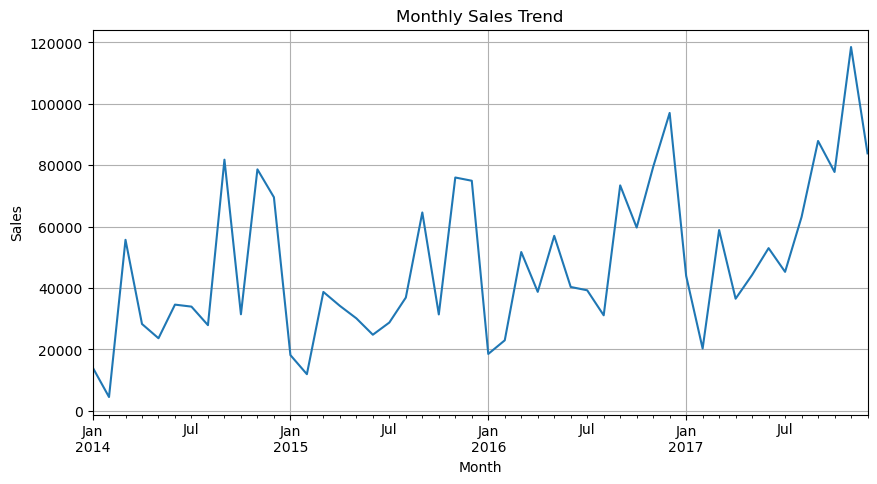

In [8]:
## Sales Trend (Time Series)

# Analyzes how sales change over time using monthly aggregation.

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()

plt.savefig("sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()

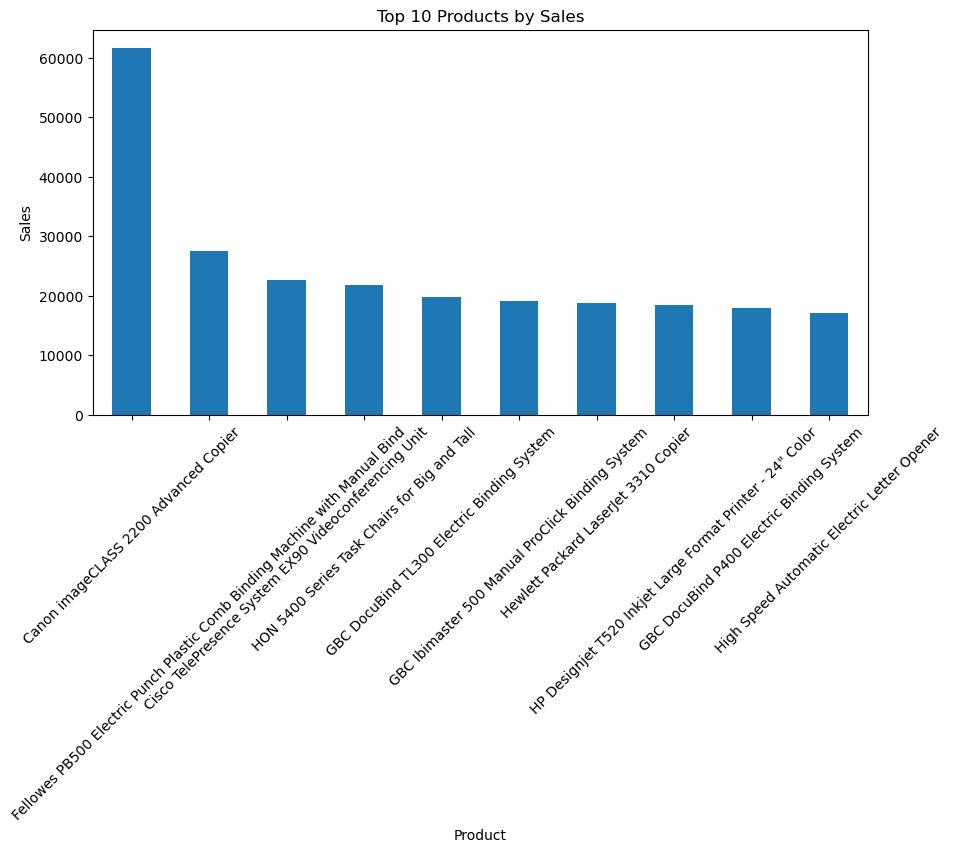

In [9]:
## Top Products Analysis

# Identifies the top-selling products based on total sales.

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.savefig("top_products.png", dpi=300, bbox_inches='tight')
plt.show()

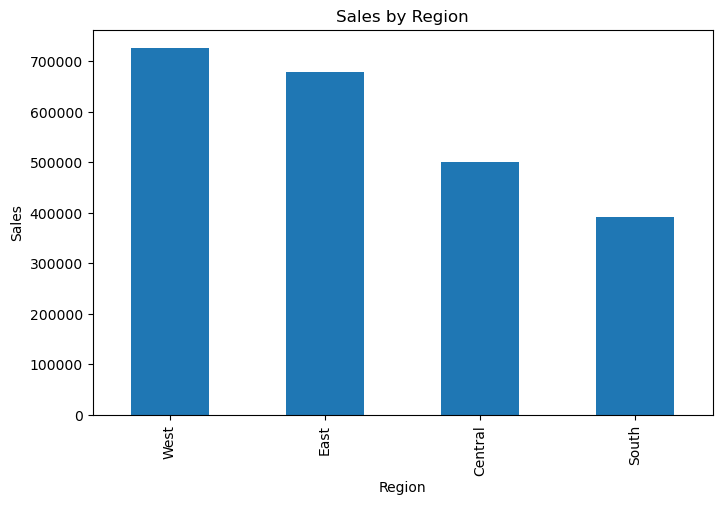

In [10]:
## Regional Sales Analysis

# Compares sales performance across different regions.

top_regions.plot(kind='bar', figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.savefig("region_sales.png", dpi=300, bbox_inches='tight')
plt.show()

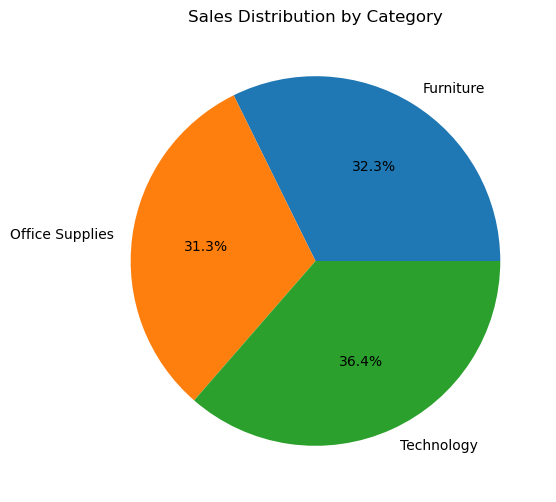

In [11]:
## Category Analysis

# Analyzes sales distribution across product categories.

category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title("Sales Distribution by Category")
plt.ylabel("")

plt.savefig("category_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
## Insights

# Sales show variation across months, indicating seasonal trends
# Certain products contribute significantly to overall revenue
# Some regions outperform others in terms of total sales
# A few categories dominate the sales distribution

In [13]:
## Recommendations

# Focus marketing efforts on top-performing products
# Improve sales strategies in lower-performing regions
# Plan inventory based on seasonal trends
# Expand high-performing categories for increased revenue